# WoE and IV walkthrough for the presentation

This notebook prepares supporting material for the business presentation: a
step-by-step look at how Weight of Evidence (WoE) and Information Value (IV)
were used to study candidate variables before they entered the final
17-variable scorecard (full development in 04_scorecard_woe.ipynb).

Four variables are walked through here, chosen to be intuitive for a
non-technical audience while representative of the different types of
variable in the final model: numeric and categorical, personal profile and
external bureau history.

In [1]:
# Import core libraries and load the train_bureau artifact
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

train_bureau = pd.read_csv('../data/processed/train_bureau.csv')
print(train_bureau.shape)

(307511, 156)


## Quick recap: WoE and IV

Weight of Evidence (WoE) measures how much a bin (a value range or category)
associates with lower or higher risk, relative to the overall client base.
Positive WoE means the bin is safer than average; negative WoE means it is
riskier. Information Value (IV) summarizes a variable's overall
discriminative power by combining the WoE of every bin.

Before any variable entered the final scorecard, its bins were checked for
monotonicity: does risk change consistently in one direction as the
variable increases, or as categories move from lower to higher risk? A
monotonic pattern is what makes a scorecard variable easy to explain to a
business audience.

In [2]:
# Define reusable WoE/IV function for numeric variables (quantile binning + explicit Missing bin, with smoothing)
def calculate_woe_iv(df, feature_col, target_col='TARGET', n_bins=10, smoothing=0.5, min_bad_per_bin=100):
    woe_df = pd.DataFrame({feature_col: df[feature_col], target_col: df[target_col]})
    woe_df['bin'] = pd.qcut(woe_df[feature_col], q=n_bins, duplicates='drop').astype('object')
    woe_df.loc[woe_df[feature_col].isnull(), 'bin'] = 'Missing'

    total_good = (woe_df[target_col] == 0).sum()
    total_bad = (woe_df[target_col] == 1).sum()

    grouped = woe_df.groupby('bin', observed=True).agg(
        n_total=(target_col, 'count'), n_bad=(target_col, 'sum')
    ).reset_index()
    grouped['n_good'] = grouped['n_total'] - grouped['n_bad']
    grouped['pct_good'] = (grouped['n_good'] + smoothing) / (total_good + smoothing * len(grouped))
    grouped['pct_bad'] = (grouped['n_bad'] + smoothing) / (total_bad + smoothing * len(grouped))
    grouped['woe'] = np.log(grouped['pct_good'] / grouped['pct_bad'])
    grouped['iv_component'] = (grouped['pct_good'] - grouped['pct_bad']) * grouped['woe']
    iv_total = grouped['iv_component'].sum()

    unstable = grouped[grouped['n_bad'] < min_bad_per_bin]
    if len(unstable) > 0:
        print(f"NOTE [{feature_col}]: {len(unstable)} bin(s) with fewer than {min_bad_per_bin} bad cases")

    return grouped[['bin', 'n_total', 'n_bad', 'pct_good', 'pct_bad', 'woe', 'iv_component']], iv_total

In [3]:
# Define reusable WoE/IV function for categorical variables (one bin per category, with smoothing)
def calculate_woe_iv_categorical(df, feature_col, target_col='TARGET', smoothing=0.5, min_bad_per_bin=100):
    woe_df = pd.DataFrame({feature_col: df[feature_col], target_col: df[target_col]})
    woe_df[feature_col] = woe_df[feature_col].astype('object').fillna('Missing')

    total_good = (woe_df[target_col] == 0).sum()
    total_bad = (woe_df[target_col] == 1).sum()

    grouped = woe_df.groupby(feature_col, observed=True).agg(
        n_total=(target_col, 'count'), n_bad=(target_col, 'sum')
    ).reset_index().rename(columns={feature_col: 'bin'})
    grouped['n_good'] = grouped['n_total'] - grouped['n_bad']
    grouped['pct_good'] = (grouped['n_good'] + smoothing) / (total_good + smoothing * len(grouped))
    grouped['pct_bad'] = (grouped['n_bad'] + smoothing) / (total_bad + smoothing * len(grouped))
    grouped['woe'] = np.log(grouped['pct_good'] / grouped['pct_bad'])
    grouped['iv_component'] = (grouped['pct_good'] - grouped['pct_bad']) * grouped['woe']
    iv_total = grouped['iv_component'].sum()

    unstable = grouped[grouped['n_bad'] < min_bad_per_bin]
    if len(unstable) > 0:
        print(f"NOTE [{feature_col}]: {len(unstable)} categor(y/ies) with fewer than {min_bad_per_bin} bad cases")

    return grouped.sort_values('woe')[['bin', 'n_total', 'n_bad', 'pct_good', 'pct_bad', 'woe', 'iv_component']], iv_total

## Example 1: Years employed (numeric, personal profile)

Business hypothesis: the longer a client has been in their current job, the
more stable their income, and the lower the risk.

In [4]:
# Calculate WoE/IV for YEARS_EMPLOYED
years_employed_woe, years_employed_iv = calculate_woe_iv(train_bureau, 'YEARS_EMPLOYED')
print(years_employed_woe.round(4).to_string(index=False))
print(f"\nIV total: {years_employed_iv:.4f}")

          bin  n_total  n_bad  pct_good  pct_bad     woe  iv_component
(-0.001, 0.9]    26366   2919    0.0829   0.1176 -0.3489        0.0121
   (0.9, 1.7]    25807   2934    0.0809   0.1182 -0.3788        0.0141
   (1.7, 2.5]    24505   2724    0.0771   0.1097 -0.3535        0.0116
   (2.5, 3.4]    24845   2543    0.0789   0.1024 -0.2611        0.0061
   (3.4, 4.5]    25387   2445    0.0812   0.0985 -0.1935        0.0034
   (4.5, 5.9]    24855   2109    0.0805   0.0850 -0.0543        0.0002
   (5.9, 7.6]    24751   1841    0.0810   0.0742  0.0887        0.0006
  (7.6, 10.1]    25855   1749    0.0853   0.0705  0.1909        0.0028
 (10.1, 14.6]    24804   1435    0.0827   0.0578  0.3576        0.0089
 (14.6, 49.1]    24962   1136    0.0843   0.0458  0.6106        0.0235
      Missing    55374   2990    0.1853   0.1204  0.4309        0.0280

IV total: 0.1113


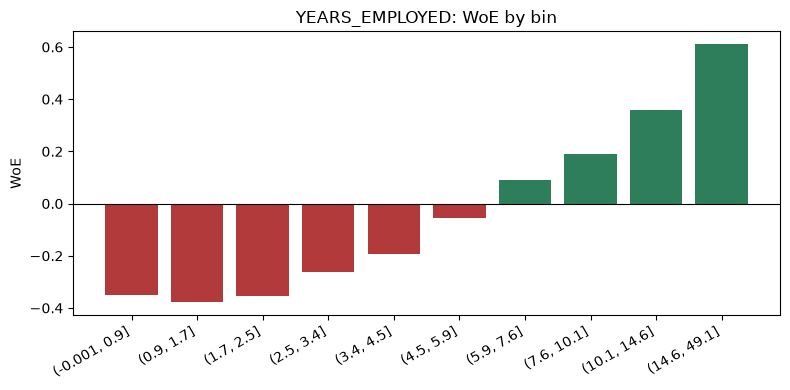

In [5]:
# Plot WoE by bin for YEARS_EMPLOYED
fig, ax = plt.subplots(figsize=(8, 4))
plot_data = years_employed_woe[years_employed_woe['bin'] != 'Missing']
colors = ['#B23A3A' if w < 0 else '#2E7D5B' for w in plot_data['woe']]
ax.bar(plot_data['bin'].astype(str), plot_data['woe'], color=colors)
ax.axhline(0, color='black', linewidth=0.8)
ax.set_ylabel('WoE')
ax.set_title('YEARS_EMPLOYED: WoE by bin')
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.show()